In [1]:
from functools import reduce
from itertools import combinations
from pathlib import Path

import numpy as np
import pandas as pd
import seaborn as sns
import statsmodels.api as sm
from rdkit.Chem import PandasTools
from rdkit.Chem.AllChem import EmbedMolecule
from rdkit.Chem.rdchem import Mol
from rdkit.Chem.rdmolfiles import (
    MolFromMolFile,
    MolFromSmiles,
    MolToMolFile,
    SDMolSupplier,
    SDWriter,
)
from rdkit.Chem.rdmolops import AddHs, CombineMols, SanitizeMol
from rdkit.Chem.rdShapeHelpers import EncodeShape, ShapeProtrudeDist
from rdkit.Geometry.rdGeometry import Point3D, UniformGrid3D
from rdkit.rdBase import DisableLog
from tqdm import tqdm

In [2]:
def add_hs(mol: Mol) -> Mol:
    try:
        assert mol is not None
        SanitizeMol(mol)
        return AddHs(mol, addCoords=True)
    except:
        return None

In [7]:
folder = Path("/homes/buttensc/Projects/semla-flow/data/conditional_xchem/02_unpacked/NCS1/aligned")
mols = [add_hs(MolFromMolFile(str(file), removeHs=False)) for file in folder.rglob("*.sdf")]
frags = [mol for mol in mols if mol.GetNumHeavyAtoms() < 18]
print(len(mols), len(frags))

129 115


<Axes: ylabel='Count'>

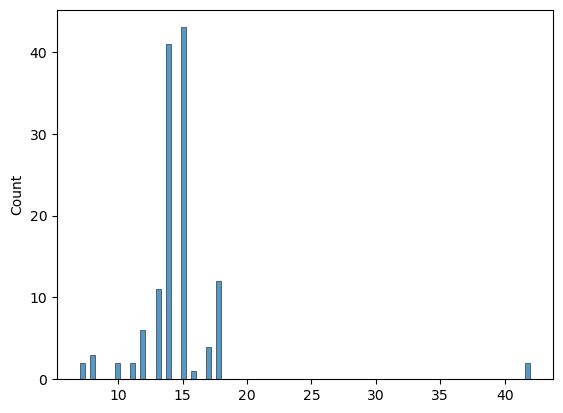

In [8]:
sns.histplot([mol.GetNumHeavyAtoms() for mol in mols])

<Axes: ylabel='Count'>

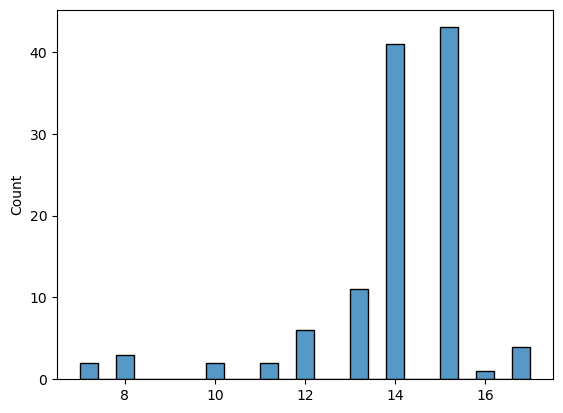

In [9]:
sns.histplot([mol.GetNumHeavyAtoms() for mol in frags])

In [15]:
combined_mol = reduce(CombineMols, frags)
combined_mol.SetProp("_Name", "NCS_fragment_hits")
MolToMolFile(combined_mol, "/homes/buttensc/Projects/semla-flow/data/conditional_xchem/03_processed/NCS1/ncs1_frags_combined.sdf")

In [16]:
writer = SDWriter("/homes/buttensc/Projects/semla-flow/data/conditional_xchem/03_processed/NCS1/ncs1_frags_separate.sdf")
for mol in mols:
    writer.write(mol)